# Classificação de sequencias

In [ ]:

!pip install 'numpy<2'

import os, random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F


from torchtext.datasets import IMDB
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator, GloVe
from collections import Counter

SEED = 1234
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


## Torchtext


```python
TEXT = data.Field(tokenize = 'spacy', include_lengths = True)
```

* Label: Categorias descritas como "pos" e "neg". Essas serão transformadas para valores numéricos {neg: 0, pos: 1}

```python
LABEL = data.LabelField(dtype = torch.long)
```



In [ ]:

!pip install 'portalocker>=2.0.0'
tokenizer = get_tokenizer('spacy', language='en_core_web_sm')


train_iter = IMDB(split='train')
test_iter = IMDB(split='test')


train_data_list = list(train_iter)
test_data_list = list(test_iter)


from sklearn.model_selection import train_test_split
train_data, valid_data = train_test_split(train_data_list, test_size=0.3, random_state=SEED)

print(f"Taille du dataset d'entraînement: {len(train_data)}")
print(f"Taille du dataset de validation: {len(valid_data)}")
print(f"Taille du dataset de test: {len(test_data_list)}")
print(f"\nExemple de donnée: label={train_data[0][0]}, texte={train_data[0][1][:100]}...")

Taille du dataset d'entraînement: 17500
Taille du dataset de validation: 7500
Taille du dataset de test: 25000

Exemple de donnée: label=1, texte="A young woman unwittingly becomes part of a kidnapping plot involving the son of a movie producer s...


In [ ]:

sample_label, sample_text = valid_data[0]
print(f"Label: {sample_label}")
print(f"Texte: {sample_text[:200]}...")
print(f"\nTokens (premiers 20): {tokenizer(sample_text)[:20]}")

Label: 1
Texte: Saw this movie when it first came out in the 1970's and hated, hated, hated it! Easily the most booooring movie I have ever seen in my life. Don't know where Leigh got his inspiration but this is one ...

Tokens (premiers 20): ['Saw', 'this', 'movie', 'when', 'it', 'first', 'came', 'out', 'in', 'the', '1970', "'s", 'and', 'hated', ',', 'hated', ',', 'hated', 'it', '!']


## Representação do Dado


### Vocabulário



In [ ]:
MAX_VOCAB_SIZE = 25_000


def yield_tokens(data_iter):
    for label, text in data_iter:
        yield tokenizer(text)

vocab = build_vocab_from_iterator(
    yield_tokens(train_data),
    max_tokens=MAX_VOCAB_SIZE,
    specials=['<unk>', '<pad>'],
    special_first=True
)
vocab.set_default_index(vocab['<unk>'])


print("Chargement des embeddings GloVe...")
glove = GloVe(name='6B', dim=100)


embedding_dim = 100
embedding_matrix = torch.zeros((len(vocab), embedding_dim))

for i, token in enumerate(vocab.get_itos()):
    if token in glove.stoi:
        embedding_matrix[i] = glove[token]
    else:

        embedding_matrix[i] = torch.randn(embedding_dim)


embedding_matrix[vocab['<pad>']] = torch.zeros(embedding_dim)

print(f'\nTaille du vocabulaire: {len(vocab)}')
print(f"Tokens spéciaux: <unk>={vocab['<unk>']}, <pad>={vocab['<pad>']}")
print(f"Exemples de tokens: {vocab.get_itos()[:10]}")

Chargement des embeddings GloVe...

Taille du vocabulaire: 25000
Tokens spéciaux: <unk>=0, <pad>=1
Exemples de tokens: ['<unk>', '<pad>', 'the', ',', '.', 'and', 'a', 'of', 'to', 'is']


In [ ]:

counter = Counter()
for label, text in train_data:
    counter.update(tokenizer(text))

print('Les 20 mots les plus fréquents:')
print(counter.most_common(20))

Les 20 mots les plus fréquents:
[('the', 202974), (',', 192406), ('.', 165627), ('and', 109476), ('a', 109243), ('of', 100850), ('to', 93733), ('is', 76635), ('in', 61135), ('I', 54465), ('it', 53549), ('that', 49039), ('"', 43860), ("'s", 43432), ('this', 42468), ('-', 37009), ('/><br', 35813), ('was', 35182), ('as', 30486), ('with', 29916)]


### Embedding Layer

Documentação Pytorch: https://pytorch.org/docs/stable/nn.html#torch.nn.Embedding




In [ ]:
class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad):
    super(RNN, self).__init__()


    self.embedding = nn.Embedding(tam_vocab, tam_embedding, padding_idx=ind_pad)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)



  def forward(self, X):
    vectors = self.embedding(X)
    return vectors


tam_vocab = len(vocab)
tam_embedding = 100 # glove 100d
embed_vectors = embedding_matrix
ind_pad = vocab['<pad>']
ind_unk = vocab['<unk>']

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad)

print(model)

RNN(
  (embedding): Embedding(25000, 100, padding_idx=1)
)


## BucketIterator


Documentação: https://torchtext.readthedocs.io/en/latest/data.html?highlight=BucketIterator#torchtext.data.BucketIterator


In [ ]:
BATCH_SIZE = 64

def text_pipeline(text):
    """Convertit le texte en liste d'indices"""
    return [vocab[token] for token in tokenizer(text)]

def label_pipeline(label):
    """Convertit le label (1=pos, 2=neg) en (1, 0)"""
    return 1 if label == 2 else 0


def collate_batch(batch):
    """
    Traite un batch de données et applique le padding
    Retourne: (textes_padded, longueurs, labels)
    """
    label_list, text_list, lengths = [], [], []

    for _label, _text in batch:

        label_list.append(label_pipeline(_label))

        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.long)
        text_list.append(processed_text)
        lengths.append(len(processed_text))


    lengths = torch.tensor(lengths, dtype=torch.long)
    sorted_indices = torch.argsort(lengths, descending=True)

    text_list = [text_list[i] for i in sorted_indices]
    label_list = [label_list[i] for i in sorted_indices]
    lengths = lengths[sorted_indices]


    text_padded = pad_sequence(text_list, batch_first=False, padding_value=vocab['<pad>'])

    label_list = torch.tensor(label_list, dtype=torch.long)

    return text_padded, lengths, label_list

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_data_list, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_batch)

print(f"Nombre de batches - Train: {len(train_loader)}, Valid: {len(valid_loader)}, Test: {len(test_loader)}")

Nombre de batches - Train: 274, Valid: 118, Test: 391


In [ ]:

for texto, tamanhos, label in valid_loader:
    print(f'Texto: {texto.shape}, Tamanhos: {tamanhos.shape}, Label: {label.shape}\n')
    print(f'Tamanhos: {tamanhos}\n')
    print(f'Labels: {label}')
    break

Texto: torch.Size([1142, 64]), Tamanhos: torch.Size([64]), Label: torch.Size([64])

Tamanhos: tensor([1142, 1096,  928,  907,  763,  705,  576,  561,  520,  467,  438,  383,
         323,  302,  295,  292,  288,  259,  228,  228,  227,  220,  203,  198,
         195,  192,  191,  184,  184,  183,  179,  175,  172,  169,  166,  165,
         164,  159,  159,  156,  156,  155,  153,  150,  149,  147,  142,  130,
         129,  126,  117,  109,  101,   94,   85,   70,   66,   62,   61,   59,
          58,   52,   50,   48])

Labels: tensor([1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
        1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1])


## Padding and Packing (Preenchendo e empacotando)




```

In [ ]:
class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size):
    super(RNN, self).__init__()


    self.embedding = nn.Embedding(tam_vocab, tam_embedding, padding_idx=ind_pad)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)



    self.hidden_size = hidden_size
    self.rnn = nn.GRU(tam_embedding, hidden_size)


  def forward(self, X, tamanhos):
    print('X:', X.size(), '\n')
    print('tamanhos', tamanhos, '\n')
    vectors = self.embedding(X)
    print('Vectors:', vectors.size(), '\n')

    hidden = torch.randn(1, X.size(1), self.hidden_size).to(X.device)

    packed_input = nn.utils.rnn.pack_padded_sequence(vectors, tamanhos.cpu())
    print('Packed input:', packed_input.batch_sizes, '\n')


    packed_output, hidden = self.rnn(packed_input, hidden)
    print('Packed output:', packed_output.batch_sizes, '\n')


    output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
    print('output:', output.size(), '\n')

    return output


tam_vocab = len(vocab)
tam_embedding = 100 # glove 100d
embed_vectors = embedding_matrix
ind_pad = vocab['<pad>']
ind_unk = vocab['<unk>']

hidden_size = 256

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size)

print(model)

RNN(
  (embedding): Embedding(25000, 100, padding_idx=1)
  (rnn): GRU(100, 256)
)


In [ ]:
for texto, tamanhos, label in valid_loader:
    saida = model(texto, tamanhos)
    break

X: torch.Size([1142, 64]) 

tamanhos tensor([1142, 1096,  928,  907,  763,  705,  576,  561,  520,  467,  438,  383,
         323,  302,  295,  292,  288,  259,  228,  228,  227,  220,  203,  198,
         195,  192,  191,  184,  184,  183,  179,  175,  172,  169,  166,  165,
         164,  159,  159,  156,  156,  155,  153,  150,  149,  147,  142,  130,
         129,  126,  117,  109,  101,   94,   85,   70,   66,   62,   61,   59,
          58,   52,   50,   48]) 

Vectors: torch.Size([1142, 64, 100]) 

Packed input: tensor([64, 64, 64,  ...,  1,  1,  1]) 

Packed output: tensor([64, 64, 64,  ...,  1,  1,  1]) 

output: torch.Size([1142, 64, 256]) 



## Classificando Sequências


In [ ]:
class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size, output_size):
    super(RNN, self).__init__()

    self.embedding = nn.Embedding(tam_vocab, tam_embedding, padding_idx=ind_pad)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)


    self.hidden_size = hidden_size
    self.rnn = nn.GRU(tam_embedding, hidden_size)
    self.linear = nn.Linear(hidden_size, output_size)


  def forward(self, X, tamanhos):
    vectors = self.embedding(X)

    hidden = torch.zeros(1, X.size(1), self.hidden_size).to(device)

    packed_input = nn.utils.rnn.pack_padded_sequence(vectors, tamanhos.cpu())
    packed_output, hidden = self.rnn(packed_input, hidden)
    output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)


    output = F.adaptive_max_pool1d(output.permute(1,2,0), 1)

    output = self.linear(output.squeeze())


    return output


tam_vocab = len(vocab)
tam_embedding = 100 # glove 100d
embed_vectors = embedding_matrix
ind_pad = vocab['<pad>']
ind_unk = vocab['<unk>']

hidden_size = 256
output_size = 2

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size, output_size)

model = model.to(device)

print(model)

RNN(
  (embedding): Embedding(25000, 100, padding_idx=1)
  (rnn): GRU(100, 256)
  (linear): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
for texto, tamanhos, label in valid_loader:
    texto = texto.to(device)
    tamanhos = tamanhos.to(device)
    label = label.to(device)
    saida = model(texto, tamanhos)
    print(f"Sortie du modèle: {saida.shape}")
    print(f"Labels: {label.shape}")
    break

Sortie du modèle: torch.Size([64, 2])
Labels: torch.Size([64])


### Loss e Otimizador

In [ ]:
criterio = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-5)

In [ ]:
def forward(iterator, num_samples, etape):
  if etape == 'Treino':
      model.train()
  else:
      model.eval()

  acuracia = 0.
  loss_epoca = []

  for k, (texto, tamanhos, rotulo) in enumerate(iterator):
      texto = texto.to(device)
      rotulo = rotulo.to(device)

      saida = model(texto, tamanhos)

      loss = criterio(saida, rotulo)
      loss_epoca.append(loss.detach().cpu().numpy())

      _, pred = torch.max(saida, axis=-1)
      acuracia += (pred.cpu().data == rotulo.cpu().data).sum()

      if etape == 'Treino':
        # Optimisation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

  loss_epoca = np.asarray(loss_epoca).ravel()
  acuracia   = acuracia/float(num_samples)
  print('\n','*'*15 + etape + '*'*15 )
  print('Epoca: {:}, Loss: {:.4f} +/- {:.4f}, Acurácia: {:.4f}'.format(epoca, loss_epoca.mean(),
                                                                        loss_epoca.std(),
                                                                        acuracia
                                                                       ))
  return loss_epoca.mean(), acuracia

In [ ]:
loss_treino, loss_test = [], []
acc_treino, acc_test = [], []

for epoca in range(25):
  loss, acuracia = forward(train_loader, len(train_data), 'Treino')
  loss_treino.append(loss)
  acc_treino.append(acuracia)

  loss, acuracia = forward(valid_loader, len(valid_data), 'Teste')
  loss_test.append(loss)
  acc_test.append(acuracia)


 ***************Treino***************
Epoca: 0, Loss: 0.6758 +/- 0.0250, Acurácia: 0.5843

 ***************Teste***************
Epoca: 0, Loss: 0.6174 +/- 0.0278, Acurácia: 0.6729

 ***************Treino***************
Epoca: 1, Loss: 0.5640 +/- 0.0645, Acurácia: 0.7103

 ***************Teste***************
Epoca: 1, Loss: 0.5251 +/- 0.0646, Acurácia: 0.7408

 ***************Treino***************
Epoca: 2, Loss: 0.4794 +/- 0.0616, Acurácia: 0.7760

 ***************Teste***************
Epoca: 2, Loss: 0.4764 +/- 0.0765, Acurácia: 0.7733

 ***************Treino***************
Epoca: 3, Loss: 0.4321 +/- 0.0625, Acurácia: 0.8061

 ***************Teste***************
Epoca: 3, Loss: 0.4329 +/- 0.0698, Acurácia: 0.8040

 ***************Treino***************
Epoca: 4, Loss: 0.3995 +/- 0.0660, Acurácia: 0.8221

 ***************Teste***************
Epoca: 4, Loss: 0.4148 +/- 0.0820, Acurácia: 0.8152

 ***************Treino***************
Epoca: 5, Loss: 0.3718 +/- 0.0676, Acurácia: 0.8382

 **

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

def predict_sentiment(sentence):
    model.eval()

    tokenized = [str(tok) for tok in nlp.tokenizer(sentence)]
    print(tokenized)


    indexed = [vocab[t] for t in tokenized]
    length = [len(indexed)]
    print(indexed)

    tensor = torch.LongTensor(indexed).to(device)
    tensor = tensor.unsqueeze(1)  # Ajouter dimension batch
    length_tensor = torch.LongTensor(length)


    with torch.no_grad():
        prediction = model(tensor, length_tensor)

    return F.softmax(prediction, dim=-1).cpu().data

['The', 'show', 'itself', 'basically', 'reflects', 'the', 'typical', 'nature', 'of', 'the', 'average', 'youth', ';', 'partying', 'and', 'picking', 'up', 'chicks', 'is', 'the', 'common', 'weekend', 'goal', 'at', 'the', 'clubs', '.', 'People', 'frown', 'upon', 'the', 'show', 'due', 'to', 'its', '"', 'perverted', '"', 'idea', 'of', 'picking', 'up', 'girls', 'using', 'technique', 'and', 'strategic', 'characterization', ',', 'but', 'truth', 'be', 'told', ',', 'practically', 'every', 'young', 'guy', 'is', 'out', 'doing', 'it', 'at', 'the', 'club', '.', 'Overall', ',', 'the', 'show', 'really', 'appeals', 'to', 'the', 'younger', 'population', ',', 'as', 'we', 'like', 'to', 'see', 'the', 'outcome', 'of', 'a', '"', 'player', "'s", '"', 'performance', 'at', 'the', 'club', ',', 'as', 'the', 'show', 'offers', 'a', 'comical', 'approach', 'made', 'possible', 'by', 'the', 'judging', 'panel', '.', '<', 'br', '/><br', '/>10/10', ';', 'a', 'cool', ',', 'fun', 'and', 'thrilling', 'series', 'that', 'allows

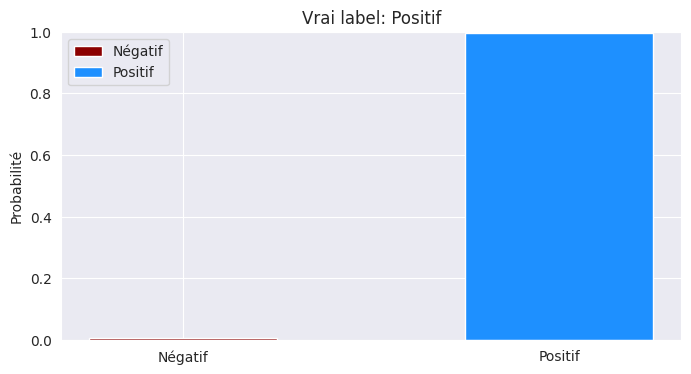

['A', 'film', 'is', 'beyond', 'all', 'expectations', ',', 'an', 'excellent', 'insight', 'into', 'the', 'human', 'condition', '.', 'What', 'exactly', 'drives', 'Mila', 'to', 'have', 'her', 'ass', 'painted', '.', 'What', 'could', 'push', 'a', 'human', 'so', 'far', 'that', 'there', 'only', 'way', 'to', 'escape', 'is', 'to', 'have', 'there', 'rear', 'passage', 'repeatedly', 'painted', 'by', 'strangers.<br', '/><br', '/>This', 'film', 'is', 'not', 'afraid', 'to', 'stair', 'squarley', 'in', 'the', 'face', 'of', 'the', 'ass', 'painting', 'issue', '.', 'Simply', 'breathtaking', '.', 'Roll', 'on', 'the', 'sequel', 'or', 'whatever', 'comes', 'next', 'from', 'the', 'geniuses', 'who', 'made', 'this', '.']
[148, 24, 9, 814, 42, 1469, 3, 43, 350, 2971, 94, 2, 454, 3336, 4, 260, 669, 3237, 0, 8, 34, 48, 1936, 4547, 4, 260, 91, 3783, 6, 454, 49, 261, 13, 67, 74, 111, 8, 1166, 9, 8, 34, 67, 7530, 7823, 4085, 4547, 40, 0, 18, 302, 24, 9, 33, 1663, 8, 0, 0, 10, 2, 437, 7, 2, 1936, 3564, 1864, 4, 5346, 32

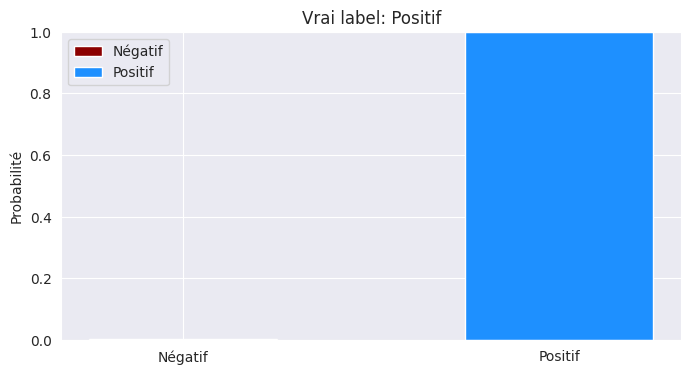

['Without', 'being', 'really', 'the', 'worst', 'science', 'fiction', 'film', 'ever', 'made', ',', 'or', 'the', 'worst', 'I', 'have', 'seen', ',', "'", 'Time', 'Under', 'Fire', "'", 'is', 'still', 'much', 'under', 'average', '.', 'The', 'premises', 'and', 'the', 'first', '10', '-', '15', 'minutes', 'are', 'not', 'that', 'bad', ',', 'it', 'starts', 'as', 'a', 'X', '-', 'Files', 'story', ',', 'combining', 'Bermuda', 'triangle', 'mysteries', 'with', 'time', 'travel', '.', 'Pretty', 'soon', 'elements', 'of', 'other', 'genres', '(', 'too', 'many', ')', 'mix', 'together', ',', 'but', 'the', 'story', 'never', 'takes', 'off', 'beyond', 'the', 'level', 'of', 'interest', 'of', 'a', 'TV', 'series', '.', 'Soon', ',', "'", 'Time', 'Under', 'Fire', "'", 'quickly', 'degenerates', 'into', 'a', 'series', 'of', 'clichés', ',', 'not', 'only', 'mixing', 'altogether', 'too', 'many', 'genres', 'but', 'also', 'being', 'unable', 'to', 'create', 'anything', 'memorable', 'in', 'suspense', 'or', 'special', 'effec

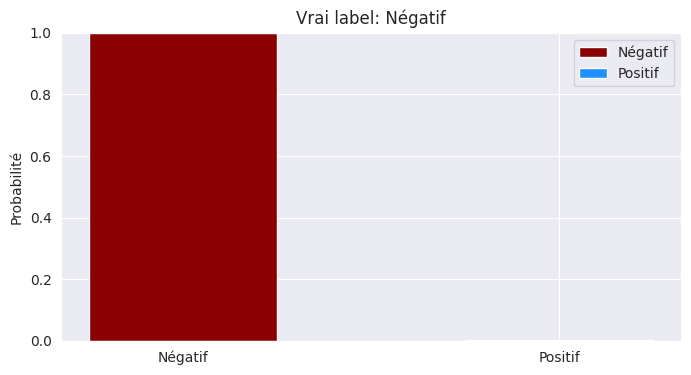

["'", 'Illuminata', "'", 'has', 'expanded', 'the', 'limits', 'of', 'John', 'Turturro', "'s", 'mediocrity', 'from', 'second', 'rate', 'actor', 'to', 'third', 'rate', 'director', ',', 'writer', 'and', 'producer', '.', 'This', 'film', 'was', 'dreadful', '.', 'It', 'is', 'disjointed', 'and', 'flits', 'from', 'scene', 'to', 'scene', 'with', 'little', 'flow', 'or', 'meaning', 'relevant', 'to', 'the', 'main', 'story', 'line.<br', '/><br', '/>We', 'are', 'served', 'with', 'a', 'smorgasbord', 'of', 'fragmented', 'scenes', ',', 'each', 'a', 'non', 'sequitur', 'to', 'all', 'the', 'others', '.', 'The', 'only', 'thread', 'that', 'seems', 'to', 'run', 'through', 'them', 'is', 'that', 'they', 'occur', 'in', 'the', 'lives', 'of', 'the', 'members', 'of', 'the', 'same', 'theatre', 'repertory', 'company', '.', 'The', 'few', 'scenes', 'that', 'do', 'matter', 'to', 'the', 'plot', 'are', 'so', 'convoluted', 'that', 'you', 'frequently', 'ca', "n't", 'tell', 'if', 'the', 'dialogue', 'is', 'from', 'the', 'stor

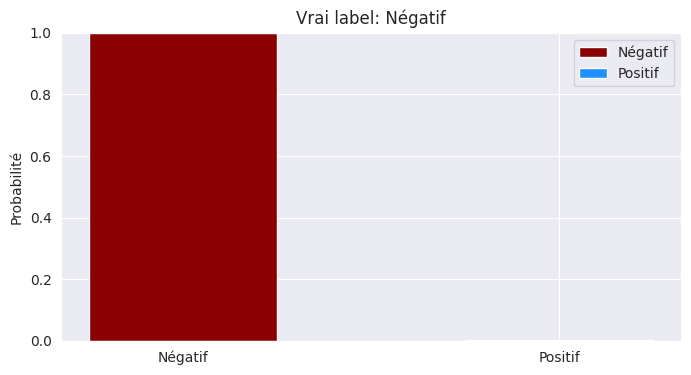

['It', "'s", 'possible', 'to', 'have', 'a', 'good', 'time', 'with', 'this', 'film', 'while', ',', 'at', 'the', 'same', 'time', ',', 'regretting', 'all', 'that', 'it', 'is', "n't", '.', 'In', 'the', '1980s', ',', 'a', 'raffish', 'U.S.', 'congressman', '(', 'Tom', 'Hanks', ')', 'engineers', 'support', 'for', 'Afghan', 'partisans', 'resisting', 'the', 'Soviet', 'Union.<br', '/><br', '/>Hanks', 'is', 'in', 'breezy', ',', 'hail', '-', 'fellow', '-', 'well', '-', 'met', 'form', 'as', 'roguish', ',', 'politically', 'incorrect', 'Charlie', 'Wilson', ',', 'first', 'glimpsed', 'sharing', 'a', 'hot', 'tub', 'with', 'three', 'deeply', 'available', 'looking', 'women', '.', 'If', 'only', 'the', 'film', 'had', 'the', 'same', 'air', 'of', 'insouciance', ';', 'but', 'apart', 'from', 'Philip', 'Seymour', 'Hoffman', "'s", 'turn', 'as', 'a', 'cynical', 'CIA', 'agent', ',', 'it', 'tries', 'to', 'be', 'perceived', 'as', 'patriotic', 'too', '.', 'Aaron', 'Sorkin', "'s", 'trademark', 'staccato', 'dialogue', '

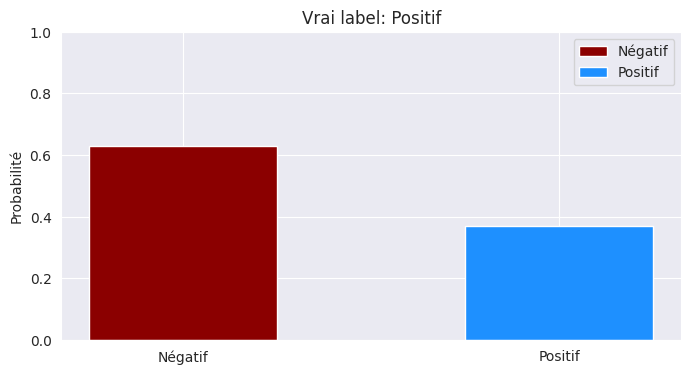

['I', 'can', 'not', 'believe', 'I', 'let', 'myself', 'rent', 'that', 'piece', 'of', 'garbage', '!', 'The', 'acting', 'was', 'so', 'poor', ',', 'my', 'Grandmother', 'could', 'have', 'done', 'better', '.', 'The', 'punches', 'thrown', 'in', 'the', 'movies', 'were', 'nowhere', 'near', 'the', 'character', 'the', 'Scarecrow', 'was', 'knocking', 'to', 'the', 'floor', '.', 'The', 'movie', 'became', 'a', 'chore', 'to', 'watch', '!', '<', 'br', '/><br', '/>So', 'this', 'group', 'of', 'baseball', 'jocks', 'decide', 'to', 'go', 'hazing', ',', 'even', 'after', 'they', 'were', "n't", 'supposed', 'to', 'in', 'orders', 'form', 'there', 'coach', 'under', 'consequences', '.', 'So', ',', 'naturally', ',', 'they', 'go', 'anyway', '.', 'They', 'decide', 'to', 'tie', 'a', 'loser', 'to', 'a', 'post', 'with', 'the', 'so', 'called', '"', 'Scarecrow', '.', '"', 'When', 'the', 'loser', "'s", 'best', 'friend', 'finds', 'out', 'about', 'this', ',', 'him', 'and', 'his', 'girlfriend', 'go', 'to', 'rescue', 'him.<br'

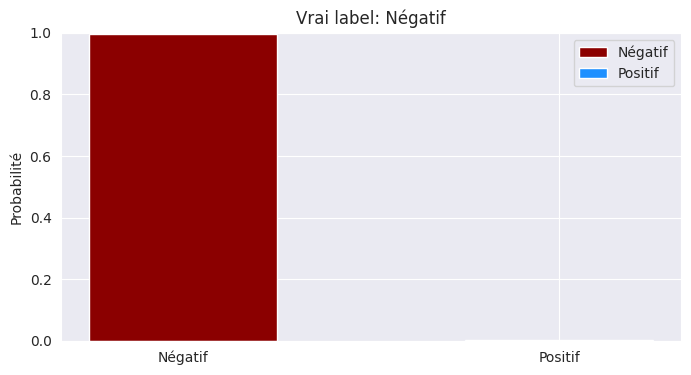

['While', 'not', 'as', 'bad', 'as', 'some', 'movies', '(', 'like', 'the', 'horrible', '"', 'Atomic', 'Twister', '"', ')', ',', '"', 'Meltdown', '"', 'still', 'relies', 'upon', 'common', 'misconceptions', 'and', 'inaccuracies', 'about', 'the', 'nuclear', 'power', 'industry', 'to', 'advance', 'its', 'plot', '.', 'I', 'am', 'currently', 'studying', 'Nuclear', 'Engineering', 'in', 'the', 'pursuit', 'of', 'a', 'Masters', 'Degree', ',', 'and', 'it', 'was', 'easy', 'to', 'point', 'out', 'flaws', 'that', 'would', 'be', 'obvious', 'to', 'anyone', 'involved', 'with', 'the', 'industry.<br', '/><br', '/>Riding', 'the', 'false', 'fear', 'that', 'a', 'Chernobyl', 'style', 'meltdown', 'could', 'happen', 'in', 'an', 'American', 'plant', ',', 'the', 'movie', 'states', 'that', 'any', 'meltdown', '(', 'even', 'partial', ',', 'according', 'to', 'one', 'of', 'the', 'guest', 'commentators', 'in', 'the', 'movie', ')', 'would', 'mean', 'disaster', 'for', 'the', 'area', '.', 'In', 'fact', ',', 'a', 'partial', 

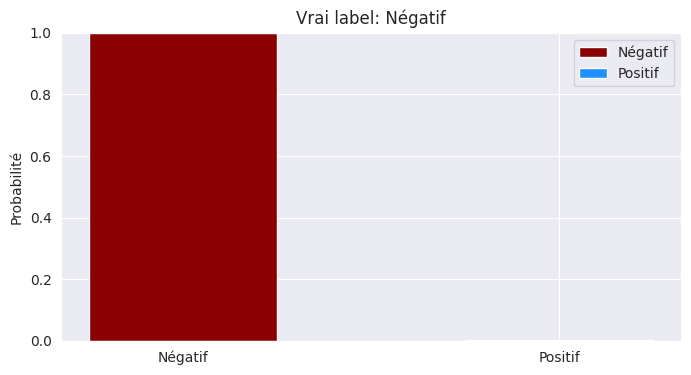

['This', 'film', 'tops', 'the', 'previous', 'incarnation', 'by', 'a', 'mile', ',', 'taking', 'everything', 'to', 'the', 'next', 'level', '.', 'As', 'always', 'the', 'JackAss', 'guys', 'are', 'purely', 'unbelievable', ',', 'and', 'I', 'personally', 'laughed', 'harder', 'in', 'that', 'theatre', 'than', 'I', 'have', 'in', 'a', 'long', 'time', '.', 'Like', 'the', 'first', 'JackAss', ',', 'this', 'is', "n't", 'so', 'much', 'a', 'movie', 'as', 'an', 'eighty', 'minute', 'long', 'string', 'of', 'stunts', 'and', 'pranks', '.', 'It', 'is', 'pure', 'circus', 'entertainment', 'taken', 'to', 'the', 'highest', 'level', '.', 'Essentially', 'these', 'guys', 'are', 'clowns', ',', 'debasing', 'themselves', 'for', 'the', 'amusement', 'of', 'others', '.', 'And', 'its', 'great', '.', 'The', 'shenanigans', 'are', 'so', 'low', ',', 'outrageous', ',', 'and', 'often', 'disgusting', 'that', 'they', 'transcend', 'into', 'a', 'higher', 'form', 'of', 'entertainment.<br', '/><br', '/>You', 'ca', "n't", 'rate', 'thi

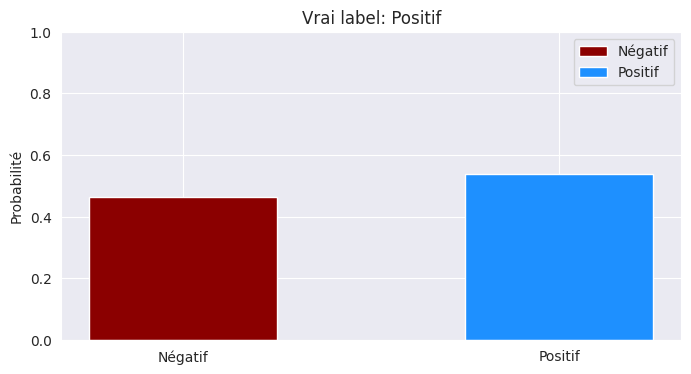

['AWFUL', 'wot', 'more', 'can', 'i', 'say', 'i', 'remember', 'seeing', 'it', 'in', 'the', 'cinema', '(', 'see', 'how', 'it', 'sticks', 'painfully', 'in', 'the', 'memory)as', 'a', '16', 'yr', 'old', 'lad', '.', 'Mark', 'Hamill', 'was', 'the', 'older', 'generations', 'skywalker', 'and', 'was', "n't", 'great', 'at', 'that', ',', 'he', 'was', 'worse', 'in', 'this', '.', 'Plus', 'a', 'dour', 'soundtrack', 'by', 'Then', 'Jericho', 'AAAAARRRRRRGGGGGGHHHHHH', '.', 'There', 'is', 'one', 'film', 'equally', 'as', 'bad', 'as', 'this', 'i', 'saw', 'in', 'the', 'cinema', 'Arthur', '2', 'on', 'the', 'rocks', '.', 'Funny', 'how', 'that', 'question', '"', 'What', 'is', 'the', 'worst', 'film', 'you', 'have', 'ever', 'seen', 'is', '?', '"', 'is', 'easier', 'than', '"', 'what', 'is', 'the', 'best', 'film', '?', '"', 'which', 'incidentally', 'varies', 'between', 'The', 'Italian', 'Job', '(', 'original', ')', ',', 'Untouchables', ',', 'Casino', ',', 'Things', 'to', 'Do', 'in', 'Denver', ',', 'Goodfellas', '

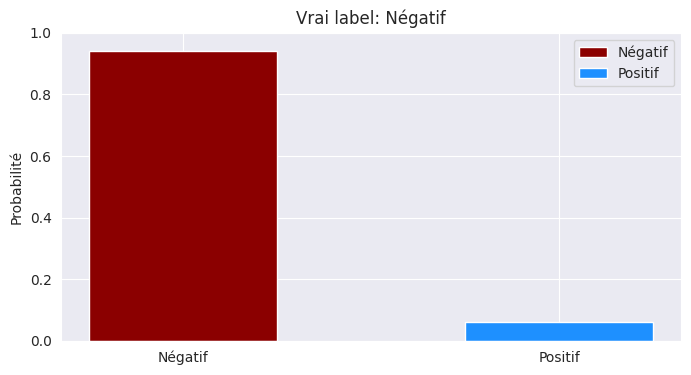

['This', 'new', 'installment', 'to', 'the', 'Child', "'s", 'Play', 'series', 'has', 'not', 'one', 'scary', 'scene', 'but', 'tons', 'of', 'hilarious', 'jokes', 'such', 'as', 'a', 'stoner', 'witnessing', 'Chucky', 'giveing', 'him', 'the', 'finger', 'and', 'saying', '"', 'rude', 'f', '--', 'king', 'doll', '"', 'and', 'lots', 'of', 'references', 'to', 'the', 'series', ':', '"', 'you', 'can', 'kill', 'me', 'but', 'I', "'ll", 'come', 'back', '.', 'I', 'always', 'come', 'back', '"', '.', 'The', 'movie', "'s", 'title', 'was', 'probably', 'thought', 'of', 'before', 'the', 'script', 'and', 'was', 'written', 'around', 'it', '.', 'This', 'is', 'totally', 'different', 'from', 'all', 'other', 'films', 'in', 'the', 'series', '.', 'It', 'does', "n't", 'even', 'have', 'Andy', ',', 'the', 'central', 'character', 'for', 'all', 'the', 'previous', 'ones', '.', 'Chucky', 'seems', 'to', 'interfere', 'with', 'characters', 'from', 'another', 'movie', ',', 'a', 'soap', 'opera', 'about', 'two', 'teens', 'running

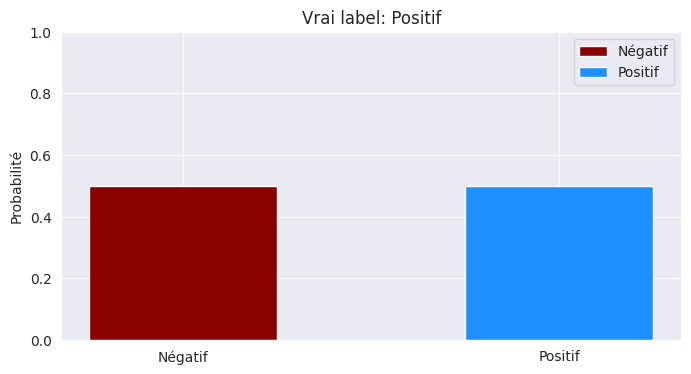

In [ ]:
np.random.seed(42)
for i in range(10):
  idx = np.random.choice(len(test_data_list))
  label, text = test_data_list[idx]


  pred = predict_sentiment(text)


  plt.figure(figsize=(8, 4))
  plt.bar(0, pred[0], color='darkred', label='Négatif', width=0.5)
  plt.bar(1, pred[1], color='dodgerblue', label='Positif', width=0.5)


  true_label = 'Positif' if label == 2 else 'Négatif'
  plt.title(f'Vrai label: {true_label}')
  plt.ylabel('Probabilité')
  plt.ylim([0, 1])
  plt.xticks([0, 1], ['Négatif', 'Positif'])
  plt.legend()
  plt.show()